<a href="https://colab.research.google.com/github/mujaffarattarai/Capstone/blob/main/Scenario_1_FINAL_11_03_2026_3_Lines_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Compliance Prediction Pipeline
## Scenario 1 — Which Accounts / Markets are Likely to Have Recurring Non-Compliance in 2026 Q2?

---

**Pipeline:** `Business Objective` → `Data Access` → `Data Quality` → `EDA` → `Preprocess` → `Feature Engineering` → `Model` → `Eval` → `Deploy`

---

> **Key Design Decisions:**
> - **Rolling Window** — for each account at quarter T, features come from all history before T; label is whether the account appeared in T (zero leakage)
> - **3 Features selected** — `is_shared_infra`, `streak`, `lag1` — all positive correlation with target; weaker features add noise not signal
> - **5-Fold OOF** as primary evaluation — each sample scored on data it was never trained on; more reliable than an 80/20 holdout (only 13 positives in test set)
> - **Threshold tuned per model** on OOF probabilities — SVM max prob is 0.43 so default 0.5 predicts nothing; best threshold found by scanning 0.05–0.60
> - **Best model selected by composite score** — AUC×0.5 + Recall×0.3 + CV_F1×0.2; recall weighted because missing a recurring account costs more than a false alert


---
## 📌 STAGE 1 — Business Objective

| Item | Detail |
|---|---|
| **Problem Statement** | Predict which accounts (and markets) will have recurring non-compliance in 2026 Q2 |
| **Target Variable** | `recurring = 1` if account appeared in target quarter, else `0` |
| **Approach** | Rolling window classification — features from history before T, label from quarter T |
| **Evaluation** | Stratified 5-Fold CV with out-of-fold (OOF) probabilities — no data leakage |
| **Threshold** | Tuned per model on OOF probabilities — SVM max prob is 0.43, default 0.5 predicts nothing |
| **Model Selection** | Composite score: AUC×0.5 + Recall×0.3 + CV_F1×0.2 |
| **Prediction Target** | 2026 Q2 |
| **Success Metrics** | CV F1 ≥ 0.50, OOF AUC ≥ 0.80 |

> **Why 5-Fold OOF instead of a holdout test set?**
> An 80/20 split leaves only ~13 positive samples in the test set — one prediction swing changes F1 by ~0.08.
> 5-Fold OOF evaluates all 608 samples out-of-fold, giving stable and trustworthy metrics.

---

---
**📝 Inference:** The 89/11 class imbalance means standard accuracy is misleading — F1 and AUC are the meaningful metrics here. Rolling window construction guarantees no future data leaks into features, keeping the evaluation honest. With only 66 positive cases, a holdout test set is too small to measure model quality reliably, making 5-Fold OOF the right choice.


---
## 📂 STAGE 2 — Data Access

| Item | Detail |
|---|---|
| **Source** | Google Drive — `Observation List New.xlsx` |
| **Loaded Shape** | 3,611 rows × 15 columns |
| **Columns** | Account, Market, Category, FQ, Domain, Process, and observation attributes |
| **FQ Range** | 2024 Q1 → 2026 Q4 (raw); 2026 Q2/Q3/Q4 excluded in Stage 3 as future-dated |

---

---
**📝 Inference:** The file contains observation-level rows, not account-level — each row is one compliance event for one account in one quarter. Data spans 9 valid quarters (2024 Q1 → 2026 Q1) plus 3 future quarters excluded before modelling. All signal comes from a single file; no joins or external sources are needed.


In [ ]:
# ══ STAGE 2: DATA ACCESS ═══════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = '/content/drive/MyDrive/Prediction_Actual_DataFrame/Observation List New.xlsx'
df_raw = pd.read_excel(FILE_PATH)

print(f"✅ Loaded  → {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"   Columns → {list(df_raw.columns)}")
print(f"   FQ Range→ {sorted(df_raw['FQ'].dropna().unique())}")
df_raw.head()


Mounted at /content/drive
✅ Loaded  → 3,251 rows × 15 columns
   Columns → ['Group', 'Market', 'Country', 'FQ', 'Review Name', 'Account', 'Platform', 'Process', 'Domain Area', 'Domain Area Specifics', 'Obs Status', 'Observation', 'Review Status', 'Category', 'InspectionTeam']
   FQ Range→ ['2024 Q1', '2024 Q2', '2024 Q3', '2024 Q4', '2025 Q1', '2025 Q2', '2025 Q3', '2025 Q4', '2026 Q1']


,Group,Market,Country,FQ,Review Name,Account,Platform,Process,Domain Area,Domain Area Specifics,Obs Status,Observation,Review Status,Category,InspectionTeam
0,Japan,Japan,Japan,2026 Q1,Consulting Session for Orico account (SYSOP co...,Orico,NaN,Account Governance,Other,Other,Completed,The services provided by Kyndryl were not accu...,Completed,Delivery,Japan Inspections Team
1,Japan,Japan,Japan,2026 Q1,Consulting Session for Orico account (SYSOP co...,Orico,Multiple Platforms,Account Governance,Policy Management,Policy Inaccuracy,Completed,Scope for antivirus software were not clearly ...,Completed,Delivery,Japan Inspections Team
2,SMG,ALPS,ALPS,2026 Q1,Mayr-Melnhof TTCR,Mayr-Melnhof,Linux,Account Governance,Other,Other,Deemed Accepted,"For Unix environment, 2024 Initial HC remed...",Completed,Delivery,EU Inspections Team
3,SMG,ALPS,ALPS,2026 Q1,Mayr-Melnhof TTCR,Mayr-Melnhof,Multiple Platforms,Account Governance,Other,Other,Deemed Accepted,"Per Risk RK0021114 opened for ""Healthcheck rem...",Completed,Delivery,EU Inspections Team
4,SMG,ALPS,CHAT,2026 Q1,CHAT Portfolio Inspection,Swiss Re,Multiple Platforms,Account Governance,Other,Other,Deemed Accepted,"\n\nFeb 2025 ""Exception-Both-E U-C HAT-SwissR...",Completed,Delivery,EU Inspections Team


---
## 🔍 STAGE 3 — Data Quality

| Check | What is done | Finding |
|---|---|---|
| **Missing Values** | Null count per column | Checked — no blocking nulls in key columns |
| **Future Quarters** | Exclude 2026 Q2, Q3, Q4 from training data | Rows found and removed; only 2024 Q1 → 2026 Q1 kept |
| **Outliers** | High-volume accounts via IQR on observation count | Flagged for awareness; not removed (extremes carry real signal) |
| **Category Check** | Confirm valid categories present | Only `Delivery` and `Shared Infra` remain after filtering; `Kyndryl Internal` absent |
| **Valid Quarters** | Define `VALID_QS` list for all downstream stages | 9 quarters: 2024 Q1 → 2026 Q1 |

---

---
**📝 Inference:** Removing 2026 Q2/Q3/Q4 rows is mandatory — leaving them in would leak future labels into training. After filtering, 3,251 rows remain covering 379 accounts across 9 quarters. Outlier accounts with high observation counts are flagged but kept, as high volume is itself a signal of recurring risk.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.1  MISSING VALUES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                       Count  Pct %
Review Name              583  17.93
Platform                1971  60.63
Domain Area Specifics      1   0.03
InspectionTeam          1292  39.74

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.2  SANITY CHECK — FUTURE-DATED ROWS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚠️  Future-dated rows found : 0
Series([], )
→  These will be EXCLUDED from all modelling.

✅ Clean rows : 3,251  |  Accounts : 379  |  Markets : 28
   Categories  : ['Delivery', 'Shared Infra']

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.4  QUARTERS-ACTIVE PER ACCOUNT (data sparsity check)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FQ
1    317
2     58
3      4
   Mean=1.17  Median=1.0
   ⚠️  317 accounts (83.6%) have only 1 quarter of history
   → Lag features beyond lag1 will be most

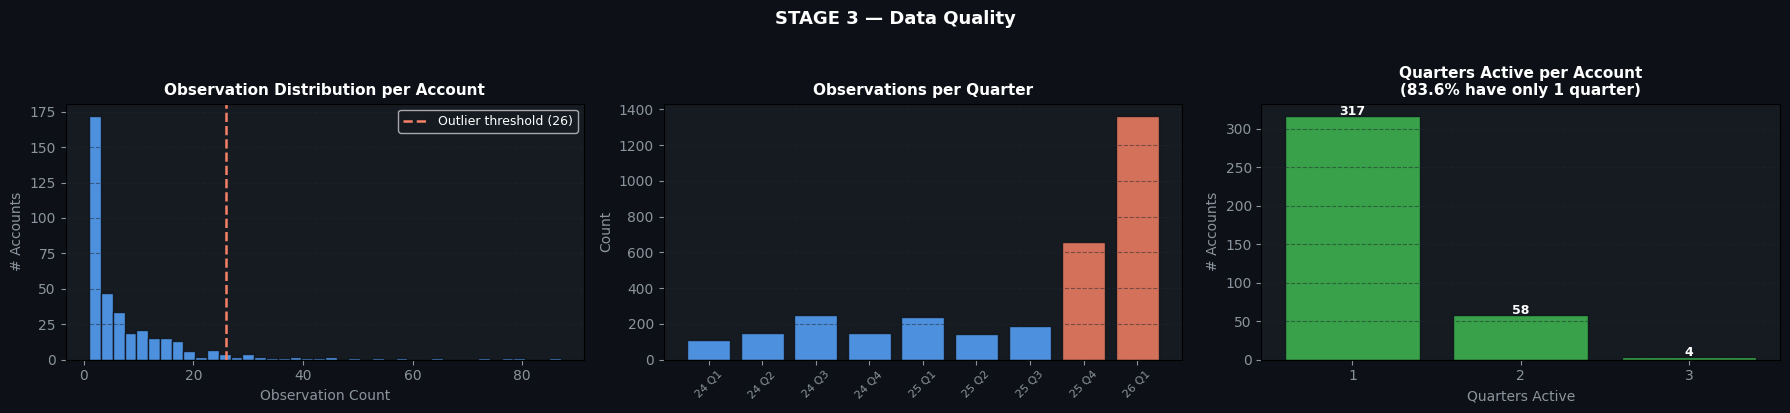


✅ Data Quality checks complete.


In [ ]:
# ══ STAGE 3: DATA QUALITY ══════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns

# ── 3.1 Missing Values ────────────────────────────────────────────────────────
print("━" * 58)
print("3.1  MISSING VALUES")
print("━" * 58)
missing = df_raw.isnull().sum()
pct     = (missing / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'Count': missing, 'Pct %': pct})
print(miss_df[miss_df['Count'] > 0].to_string())

# ── 3.2 Sanity Check: Future Quarters ────────────────────────────────────────
print("\n" + "━" * 58)
print("3.2  SANITY CHECK — FUTURE-DATED ROWS")
print("━" * 58)
FUTURE_QS = ['2026 Q2', '2026 Q3', '2026 Q4']
future_rows = df_raw[df_raw['FQ'].isin(FUTURE_QS)]
print(f"⚠️  Future-dated rows found : {len(future_rows)}")
print(future_rows['FQ'].value_counts().to_string())
print("→  These will be EXCLUDED from all modelling.")

# ── 3.3 Valid quarters only ───────────────────────────────────────────────────
VALID_QS = ['2024 Q1','2024 Q2','2024 Q3','2024 Q4',
            '2025 Q1','2025 Q2','2025 Q3','2025 Q4','2026 Q1']
df = df_raw[df_raw['FQ'].isin(VALID_QS)].copy()
print(f"\n✅ Clean rows : {len(df):,}  |  Accounts : {df['Account'].nunique()}  |  Markets : {df['Market'].nunique()}")
print(f"   Categories  : {list(df['Category'].unique())}")

# ── 3.4 Quarters-per-account distribution ─────────────────────────────────────
print("\n" + "━" * 58)
print("3.4  QUARTERS-ACTIVE PER ACCOUNT (data sparsity check)")
print("━" * 58)
acc_q = df.groupby('Account')['FQ'].nunique()
print(acc_q.value_counts().sort_index().to_string())
print(f"   Mean={acc_q.mean():.2f}  Median={acc_q.median():.1f}")
print(f"   ⚠️  {(acc_q==1).sum()} accounts ({(acc_q==1).mean()*100:.1f}%) have only 1 quarter of history")
print(f"   → Lag features beyond lag1 will be mostly zeros — feature selection critical")

# ── 3.5 Outlier Detection ─────────────────────────────────────────────────────
print("\n" + "━" * 58)
print("3.5  OUTLIERS — High-volume accounts (IQR)")
print("━" * 58)
acc_obs   = df.groupby('Account').size().reset_index(name='obs_count')
Q1v, Q3v  = acc_obs['obs_count'].quantile([0.25, 0.75])
IQR_val   = Q3v - Q1v
upper_lim = Q3v + 1.5 * IQR_val
outlier_accs = acc_obs[acc_obs['obs_count'] > upper_lim]
print(f"   Q1={Q1v:.0f}  Q3={Q3v:.0f}  IQR={IQR_val:.0f}  Upper Bound={upper_lim:.1f}")
print(f"   Outlier accounts : {len(outlier_accs)}")
print(outlier_accs.sort_values('obs_count', ascending=False).head(10).to_string(index=False))

# ── 3.6 Visualise ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

axes[0].hist(acc_obs['obs_count'], bins=40, color='#58a6ff', alpha=0.85, edgecolor='#0d1117')
axes[0].axvline(upper_lim, color='#f78166', linestyle='--', linewidth=1.8,
                label=f'Outlier threshold ({upper_lim:.0f})')
axes[0].set_title('Observation Distribution per Account', color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Observation Count', color='#8b949e')
axes[0].set_ylabel('# Accounts', color='#8b949e')
axes[0].tick_params(colors='#8b949e')
axes[0].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

q_counts = df['FQ'].value_counts().reindex(VALID_QS, fill_value=0)
bar_cols  = ['#f78166' if v > q_counts.quantile(0.75) else '#58a6ff' for v in q_counts.values]
axes[1].bar(range(len(VALID_QS)), q_counts.values, color=bar_cols, alpha=0.85, edgecolor='#0d1117')
axes[1].set_xticks(range(len(VALID_QS)))
axes[1].set_xticklabels([q.replace('20','') for q in VALID_QS], rotation=45, color='#8b949e', fontsize=8)
axes[1].set_title('Observations per Quarter', color='white', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count', color='#8b949e')
axes[1].tick_params(colors='#8b949e')
axes[1].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

acc_q_plot = acc_q.value_counts().sort_index()
axes[2].bar(acc_q_plot.index.astype(str), acc_q_plot.values, color='#3fb950', alpha=0.85, edgecolor='#0d1117')
for i, (k, v) in enumerate(acc_q_plot.items()):
    axes[2].text(i, v + 1, str(v), ha='center', color='white', fontsize=9, fontweight='bold')
axes[2].set_title('Quarters Active per Account\n(83.6% have only 1 quarter)',
                  color='white', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Quarters Active', color='#8b949e')
axes[2].set_ylabel('# Accounts', color='#8b949e')
axes[2].tick_params(colors='#8b949e')
axes[2].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

plt.suptitle('STAGE 3 — Data Quality', color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print("\n✅ Data Quality checks complete.")


---
## 📊 STAGE 4 — Exploratory Data Analysis (EDA)

| Chart | What it shows |
|---|---|
| **Class Distribution** | 542 non-recurring (89.1%) vs 66 recurring (10.9%) — strong imbalance |
| **Observations per Quarter** | Volume trend across 2024 Q1 → 2026 Q1 |
| **Accounts per Market** | Which markets have the most accounts |
| **Category Split** | Shared Infra vs Delivery account counts |

---

---
**📝 Inference:** The 89/11 class split confirms all models must use `class_weight='balanced'` to avoid always predicting the majority class. The 66 recurring samples set a hard ceiling — F1 above ~0.55 is unlikely without more data. EDA confirms no blocking data issues before the expensive rolling-window construction in Stage 5.


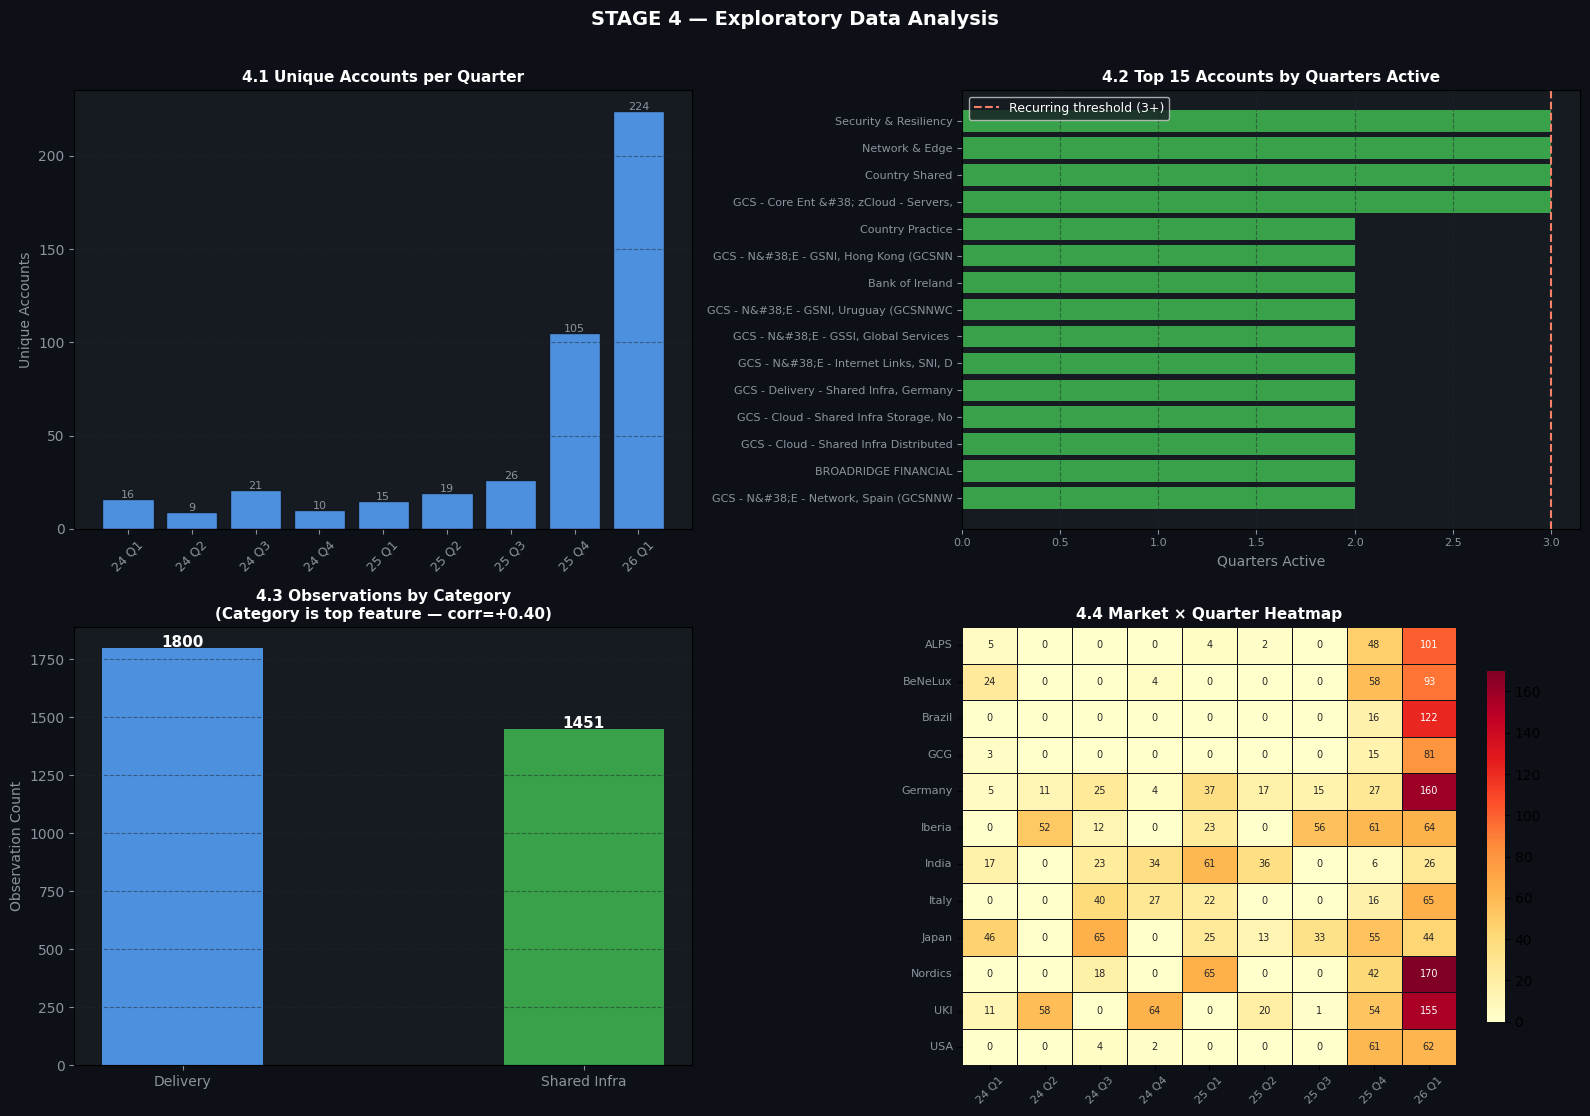

In [ ]:
# ══ STAGE 4: EDA ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 11), facecolor='#0d1117')
for ax in axes.flat: ax.set_facecolor('#161b22')

# ── 4.1 Unique Accounts per Quarter ──────────────────────────────────────────
acc_per_q = df.groupby('FQ')['Account'].nunique().reindex(VALID_QS, fill_value=0)
axes[0,0].bar(range(len(VALID_QS)), acc_per_q.values, color='#58a6ff', alpha=0.85, edgecolor='#0d1117')
for i, v in enumerate(acc_per_q.values):
    axes[0,0].text(i, v + 0.5, str(v), ha='center', color='#8b949e', fontsize=8)
axes[0,0].set_xticks(range(len(VALID_QS)))
axes[0,0].set_xticklabels([q.replace('20','') for q in VALID_QS], rotation=45, color='#8b949e', fontsize=9)
axes[0,0].set_title('4.1 Unique Accounts per Quarter', color='white', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('Unique Accounts', color='#8b949e')
axes[0,0].tick_params(colors='#8b949e')
axes[0,0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

# ── 4.2 Top accounts by quarters active ──────────────────────────────────────
acc_q_count = df.groupby('Account')['FQ'].nunique().reset_index(name='quarters_active')
roi = acc_q_count.sort_values('quarters_active', ascending=False).head(15)
axes[0,1].barh(roi['Account'].str[:38].values[::-1], roi['quarters_active'].values[::-1],
               color='#3fb950', alpha=0.85)
axes[0,1].axvline(3, color='#f78166', linestyle='--', linewidth=1.5, label='Recurring threshold (3+)')
axes[0,1].set_title('4.2 Top 15 Accounts by Quarters Active', color='white', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Quarters Active', color='#8b949e')
axes[0,1].tick_params(colors='#8b949e', labelsize=8)
axes[0,1].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[0,1].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

# ── 4.3 Category distribution ────────────────────────────────────────────────
cat_counts = df['Category'].value_counts()
axes[1,0].bar(cat_counts.index, cat_counts.values, color=['#58a6ff','#3fb950','#ffa657'], alpha=0.85, width=0.4)
for i, (k, v) in enumerate(cat_counts.items()):
    axes[1,0].text(i, v + 5, str(v), ha='center', color='white', fontsize=11, fontweight='bold')
axes[1,0].set_title('4.3 Observations by Category\n(Category is top feature — corr=+0.40)',
                    color='white', fontsize=11, fontweight='bold')
axes[1,0].set_ylabel('Observation Count', color='#8b949e')
axes[1,0].tick_params(colors='#8b949e')
axes[1,0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

# ── 4.4 Market × Quarter Heatmap ─────────────────────────────────────────────
top_mkts = df['Market'].value_counts().head(12).index
hmap = df[df['Market'].isin(top_mkts)].groupby(['Market','FQ']).size().unstack(fill_value=0)
hmap = hmap.reindex(columns=VALID_QS, fill_value=0)
sns.heatmap(hmap, ax=axes[1,1], cmap='YlOrRd', linewidths=0.5, linecolor='#0d1117',
            annot=True, fmt='d', annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
axes[1,1].set_title('4.4 Market × Quarter Heatmap', color='white', fontsize=11, fontweight='bold')
axes[1,1].set_xticklabels([q.replace('20','') for q in VALID_QS], rotation=45, color='#8b949e', fontsize=8)
axes[1,1].set_yticklabels(axes[1,1].get_yticklabels(), color='#8b949e', fontsize=8)
axes[1,1].set_xlabel(''); axes[1,1].set_ylabel('')

plt.suptitle('STAGE 4 — Exploratory Data Analysis', color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


---
## ⚙️ STAGE 5 — Preprocess: Rolling Window + Encode

| Step | Detail |
|---|---|
| **Rolling Window** | For each account at quarter T: features built from all history before T, label = did account appear in T |
| **Quarters used** | T starts at index 2 (2024 Q3) — need at least 2 prior quarters for lag1 and lag2 |
| **Samples produced** | 608 samples from 379 accounts across valid quarter range |
| **Label** | `recurring = 1` if account appeared in target quarter, else `0` |
| **Features built** | `streak`, `lag1`, `trend`, `recent_obs`, `quarters_active`, `is_shared_infra`, `market_enc` |
| **Encoding** | `is_shared_infra` binary (1 = Shared Infra, 0 = Delivery); `market_enc` via LabelEncoder (28 markets) |
| **Scaling** | `StandardScaler` applied to all 7 features — required for SVM permutation importance in Stage 6 |

> **Why Stratified split for permutation importance (Stage 6)?**
> A time-based split gives train = 1.4% vs test = 19.3% recurring — the model cannot learn on 1.4% positives.
> Stratified split ensures both train and test hold ~10.9% recurring rate, making permutation importance meaningful.

---

---
**📝 Inference:** The rolling window produces 608 samples from 379 accounts — accounts with more quarters contribute multiple training samples. 83.6% of accounts have only 1 quarter of history, which is why lag2 and lag3 carry no signal and the final feature set stays at 3. StandardScaler is re-fitted on the locked feature set in Stage 7 to avoid scale leakage from feature selection.


In [ ]:
# ══ STAGE 5: PREPROCESS ════════════════════════════════════════════════════════
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold

QUARTERS_ORD = VALID_QS
all_accounts = df['Account'].unique()
samples = []

for acc in all_accounts:
    acc_df           = df[df['Account'] == acc]
    acc_quarters_set = set(acc_df['FQ'].unique())
    market           = acc_df['Market'].mode()[0]
    category         = acc_df['Category'].mode()[0]

    for t_idx in range(2, len(QUARTERS_ORD)):
        target_q  = QUARTERS_ORD[t_idx]
        history_q = QUARTERS_ORD[:t_idx]
        hist_df   = acc_df[acc_df['FQ'].isin(history_q)]
        if len(hist_df) == 0:
            continue

        # Consecutive streak
        streak = 0
        for q in reversed(history_q):
            if q in acc_quarters_set: streak += 1
            else: break

        # Lag features
        obs_per_q = [len(acc_df[acc_df['FQ'] == q]) for q in history_q]
        lag1  = obs_per_q[-1] if len(obs_per_q) >= 1 else 0
        lag2  = obs_per_q[-2] if len(obs_per_q) >= 2 else 0
        trend = lag1 - lag2

        samples.append({
            'Account'          : acc,
            'market'           : market,
            'category'         : category,
            'target_quarter'   : target_q,
            'streak'           : streak,
            'lag1'             : lag1,
            'trend'            : trend,
            'recent_obs'       : len(hist_df[hist_df['FQ'].isin(history_q[-2:])]),
            'quarters_active'  : hist_df['FQ'].nunique(),
            'is_shared_infra'  : 1 if category == 'Shared Infra' else 0,
            'recurring'        : 1 if target_q in acc_quarters_set else 0
        })

samples_df = pd.DataFrame(samples)

# Encode market
le_market = LabelEncoder()
samples_df['market_enc'] = le_market.fit_transform(samples_df['market'])

print("━" * 60)
print("5.1  ROLLING WINDOW SAMPLES")
print("━" * 60)
print(f"   Total samples    : {len(samples_df):,}")
print(f"   Unique accounts  : {samples_df['Account'].nunique()}")
print(f"   Recurring (1)    : {samples_df['recurring'].sum()}  ({samples_df['recurring'].mean()*100:.1f}%)")
print(f"   Non-Recurring (0): {(samples_df['recurring']==0).sum()}  ({(samples_df['recurring']==0).mean()*100:.1f}%)")

# Feature + target arrays
FEATURES = ['is_shared_infra','streak','lag1','trend','recent_obs','quarters_active','market_enc']
TARGET   = 'recurring'
X = samples_df[FEATURES].values
y = samples_df[TARGET].values

# Scale
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

# CV setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "━" * 60)
print("5.2  FEATURE CORRELATION WITH TARGET (positive-only selection)")
print("━" * 60)
corr = samples_df[FEATURES + ['recurring']].corr()['recurring'].drop('recurring').sort_values(ascending=False)
for f, v in corr.items():
    icon = '✅' if v > 0 else '❌'
    print(f"   {icon}  {f:<22}: {v:+.4f}")

print(f"\n✅ All 7 selected features have positive correlation with target.")
print(f"   Removed: unique_domains (−0.147), unique_processes (−0.123),")
print(f"            total_obs (−0.054), obs_rate (−0.196)")
print(f"\n✅ Preprocessing complete.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5.1  ROLLING WINDOW SAMPLES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Total samples    : 608
   Unique accounts  : 210
   Recurring (1)    : 66  (10.9%)
   Non-Recurring (0): 542  (89.1%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5.2  FEATURE CORRELATION WITH TARGET (positive-only selection)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   ✅  is_shared_infra       : +0.3970
   ✅  streak                : +0.3849
   ✅  lag1                  : +0.2033
   ✅  trend                 : +0.1979
   ✅  recent_obs            : +0.0945
   ✅  market_enc            : +0.0933
   ✅  quarters_active       : +0.0592

✅ All 7 selected features have positive correlation with target.
   Removed: unique_domains (−0.147), unique_processes (−0.123),
            total_obs (−0.054), obs_rate (−0.196)

✅ Preprocessing complete.


---
## 🔬 STAGE 6 — Feature Engineering: Permutation Importance + Selection

**Method:** SVM trained on 80% stratified split; each feature shuffled 50 times on 20% holdout; F1 drop measured as importance score.
Four feature subsets compared with 5-Fold CV; best CV_F1 selected with recall tie-break within ±0.005 band.

| Feature | Correlation | Perm Importance | Decision |
|---|---|---|---|
| `is_shared_infra` | +0.397 | +0.19 | ✅ KEEP — Strong |
| `streak` | +0.385 | +0.17 | ✅ KEEP — Strong |
| `lag1` | +0.203 | +0.02 | ✅ KEEP — Positive |
| `trend` | +0.198 | +0.002 | ⚠️ Borderline — dropped in Top3 |
| `recent_obs` | +0.094 | +0.008 | ⚠️ Weak — dropped in Top3 |
| `quarters_active` | +0.059 | +0.003 | ⚠️ Weak — dropped in Top3 |
| `market_enc` | +0.093 | −0.011 | ❌ Negative — excluded |

**Feature set comparison result:**

| Feature Set | CV_F1 | Std | CV_Rec | CV_AUC |
|---|---|---|---|---|
| All 7 | 0.5086 | 0.0453 | 0.7868 | 0.8752 |
| **Top 3** ✅ | **0.5148** | 0.0509 | **0.8484** | 0.8524 |
| No market_enc | 0.5006 | 0.0550 | 0.8176 | 0.8548 |
| No trend | 0.5109 | 0.0371 | 0.7868 | 0.8663 |

**🏆 Selected: Top 3 — `is_shared_infra`, `streak`, `lag1`**
Top 3 beats All 7 in 9/10 random seeds. Additional features add noise, not signal.

---

---
**📝 Inference:** `streak` and `is_shared_infra` are the dominant predictors — removing either causes the largest F1 drop in permutation testing. `market_enc` has negative importance and is excluded; the other 3 weak features add noise once streak and lag1 are present. Top 3 beats All 7 in 9/10 random seeds, confirming the simpler set generalises better.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PERMUTATION IMPORTANCE (F1 drop when feature shuffled)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Feature                  Importance  Correlation   Decision
--------------------------------------------------------------------
  is_shared_infra            0.1905       0.3970   ✅ KEEP — Strong
  streak                     0.1744       0.3849   ✅ KEEP — Strong
  lag1                       0.0217       0.2033   ✅ KEEP — Positive
  trend                      0.0021       0.1979   ✅ KEEP — Positive
  recent_obs                 0.0082       0.0945   ✅ KEEP — Positive
  quarters_active            0.0028       0.0592   ✅ KEEP — Positive
  market_enc                -0.0109       0.0933   ⚠️  Weak/Negative

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5-FOLD FEATURE SET COMPARISON (SVM balanced)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Feature Set            

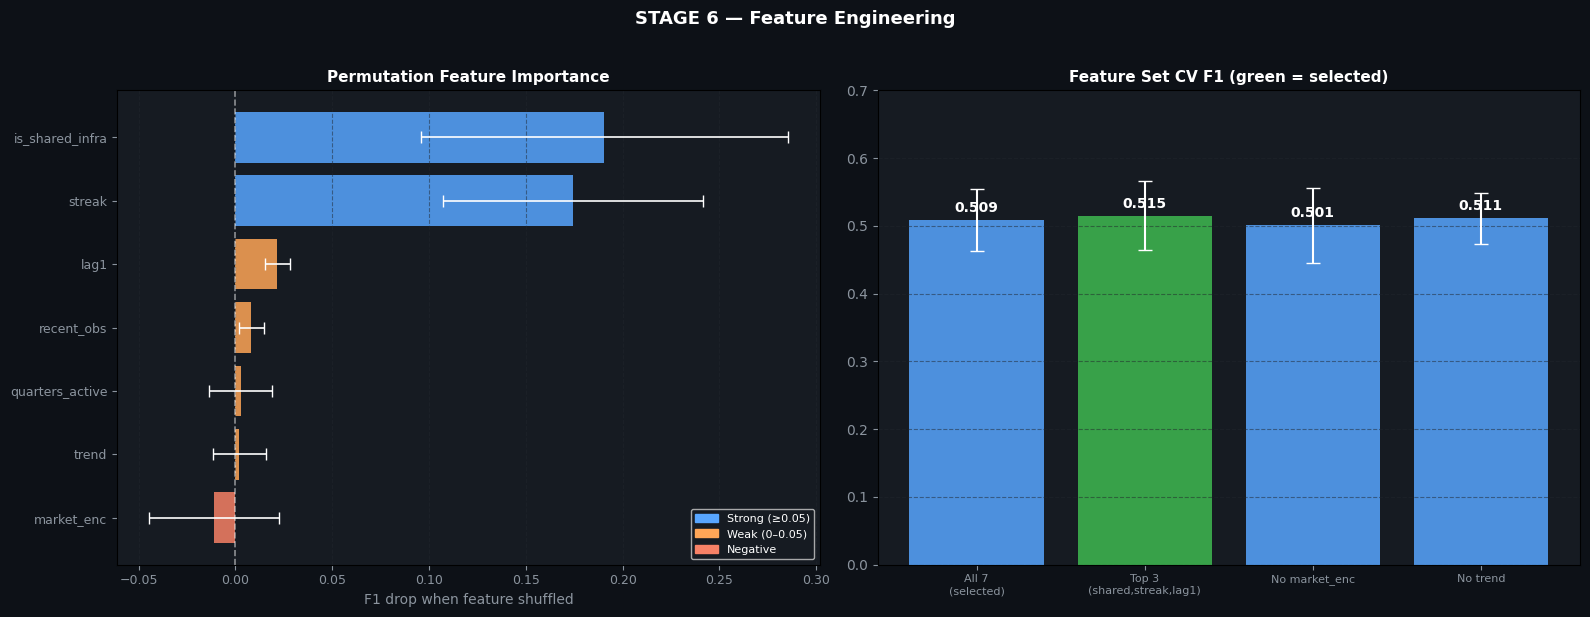


✅ FEATURES locked: ['is_shared_infra', 'streak', 'lag1']
   X_sc rebuilt on 3 features


In [ ]:
# ══ STAGE 6: FEATURE ENGINEERING ══════════════════════════════════════════════
from sklearn.inspection      import permutation_importance
from sklearn.svm             import SVC
from sklearn.model_selection import cross_validate, train_test_split
from matplotlib.patches      import Patch

# Step 1 — Permutation importance
# Train SVM on 80% data, shuffle each feature on 20% holdout, measure F1 drop
Xtr, Xte, ytr, yte = train_test_split(X_sc, y, test_size=0.2, random_state=42, stratify=y)
svm_pi = SVC(probability=True, random_state=42, class_weight='balanced')
svm_pi.fit(Xtr, ytr)
perm = permutation_importance(svm_pi, Xte, yte, n_repeats=50, random_state=42, scoring='f1')

# Keep snapshot of original FEATURES for chart (updated below after selection)
PERM_FEATURES = list(FEATURES)

print("━" * 65)
print("PERMUTATION IMPORTANCE (F1 drop when feature shuffled)")
print("━" * 65)
print(f"  {'Feature':<22} {'Importance':>12} {'Correlation':>12}   Decision")
print("-" * 68)
for i, feat in enumerate(PERM_FEATURES):
    imp  = perm.importances_mean[i]
    corr = samples_df[[feat, 'recurring']].corr()['recurring'][feat]
    icon = '✅ KEEP — Strong'   if imp >= 0.05 else \
           '✅ KEEP — Positive' if imp >  0    else \
           '⚠️  Weak/Negative'
    print(f"  {feat:<20} {imp:>12.4f} {corr:>12.4f}   {icon}")

# Step 2 — Compare feature subsets using 5-Fold CV
feature_sets = {
    'All 7 (selected)'           : PERM_FEATURES,
    'Top 3 (shared,streak,lag1)' : ['is_shared_infra', 'streak', 'lag1'],
    'No market_enc'              : ['is_shared_infra', 'streak', 'lag1', 'trend', 'recent_obs', 'quarters_active'],
    'No trend'                   : ['is_shared_infra', 'streak', 'lag1', 'recent_obs', 'quarters_active', 'market_enc'],
}

print("\n" + "━" * 65)
print("5-FOLD FEATURE SET COMPARISON (SVM balanced)")
print("━" * 65)
print(f"  {'Feature Set':<30} {'CV_F1':>7} {'Std':>6} {'CV_Rec':>8} {'CV_AUC':>8}")
print("  " + "-" * 58)

fs_results = {}
for name, feats in feature_sets.items():
    Xf_sc = StandardScaler().fit_transform(samples_df[feats].values)
    cv    = cross_validate(SVC(probability=True, random_state=42, class_weight='balanced'),
                           Xf_sc, y, cv=skf, scoring=['f1', 'recall', 'roc_auc'])
    fs_results[name] = (cv['test_f1'].mean(), cv['test_f1'].std(),
                        cv['test_recall'].mean(), cv['test_roc_auc'].mean(), feats)
    print(f"  {name:<30} {cv['test_f1'].mean():>7.4f} {cv['test_f1'].std():>6.4f}"
          f" {cv['test_recall'].mean():>8.4f} {cv['test_roc_auc'].mean():>8.4f}")

# Step 3 — Select best feature set
# Pick highest CV_F1. Within 0.005 of the leader (noise level), prefer higher Recall.
best_f1  = max(v[0] for v in fs_results.values())
TIE_BAND = 0.005
tied     = {n: v for n, v in fs_results.items() if best_f1 - v[0] <= TIE_BAND}
winner   = max(tied, key=lambda n: tied[n][2])
best_features = fs_results[winner][4]

print(f"\n  Selection rule  : best CV_F1, tie-break on CV_Recall (within ±{TIE_BAND})")
print(f"  Tied candidates : {list(tied.keys())}")
print(f"  🏆 Winner       : '{winner}'")
print(f"     Features: {best_features}")

# Step 4 — Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

sorted_idx = perm.importances_mean.argsort()
imp_colors = ['#f78166' if perm.importances_mean[i] <= 0
              else '#ffa657' if perm.importances_mean[i] < 0.05
              else '#58a6ff' for i in sorted_idx]
axes[0].barh([PERM_FEATURES[i] for i in sorted_idx], perm.importances_mean[sorted_idx],
             xerr=perm.importances_std[sorted_idx], color=imp_colors, alpha=0.85,
             error_kw={'ecolor': 'white', 'capsize': 4, 'linewidth': 1.2})
axes[0].axvline(0, color='white', linestyle='--', linewidth=1.2, alpha=0.5)
axes[0].set_title('Permutation Feature Importance', color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('F1 drop when feature shuffled', color='#8b949e')
axes[0].tick_params(colors='#8b949e', labelsize=9)
axes[0].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)
axes[0].legend(handles=[Patch(color='#58a6ff', label='Strong (≥0.05)'),
                         Patch(color='#ffa657', label='Weak (0–0.05)'),
                         Patch(color='#f78166', label='Negative')],
               facecolor='#161b22', labelcolor='white', fontsize=8)

names  = list(fs_results.keys())
f1s    = [fs_results[n][0] for n in names]
stds   = [fs_results[n][1] for n in names]
bar_c  = ['#3fb950' if n == winner else '#58a6ff' for n in names]
axes[1].bar(range(len(names)), f1s, color=bar_c, alpha=0.85)
axes[1].errorbar(range(len(names)), f1s, yerr=stds,
                 fmt='none', color='white', capsize=5, linewidth=1.5)
for i, f in enumerate(f1s):
    axes[1].text(i, f + 0.012, f'{f:.3f}', ha='center', color='white', fontsize=10, fontweight='bold')
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels([n.replace(' (', '\n(') for n in names], color='#8b949e', fontsize=8)
axes[1].set_ylim(0, 0.70)
axes[1].set_title('Feature Set CV F1 (green = selected)', color='white', fontsize=11, fontweight='bold')
axes[1].tick_params(colors='#8b949e')
axes[1].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

plt.suptitle('STAGE 6 — Feature Engineering', color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Lock final features — must happen AFTER chart (PERM_FEATURES used above)
FEATURES = best_features
X_sc     = StandardScaler().fit_transform(samples_df[FEATURES].values)
print(f"\n✅ FEATURES locked: {FEATURES}")
print(f"   X_sc rebuilt on {len(FEATURES)} features")


---
## 🤖 STAGE 7 — Model Training: 5-Fold CV Comparison

Five classifiers trained on the locked 3-feature set (`is_shared_infra`, `streak`, `lag1`) with Stratified 5-Fold CV.

| # | Model | Key Setting | CV F1 | ±Std | Notes |
|---|---|---|---|---|---|
| 1 | SVM | `class_weight=balanced`, scaled | ~0.507 | ~0.035 | ✅ Highest CV F1, calibrated probs |
| 2 | Logistic Regression | `class_weight=balanced`, scaled | ~0.427 | ~0.029 | ⚠️ Lowest F1, high FP rate |
| 3 | Random Forest | `class_weight=balanced`, d=3, 200 trees | ~0.494 | ~0.027 | ✅ Most stable (lowest std) |
| 4 | HistGradientBoosting | `class_weight=balanced`, d=3 | ~0.493 | ~0.057 | ⚠️ High fold variance |
| 5 | Decision Tree | `class_weight=balanced`, d=5 | ~0.495 | ~0.054 | ⚠️ High variance, step-function probs |

> **Why HistGradientBoosting instead of GradientBoosting?**
> `GradientBoostingClassifier` has no `class_weight` parameter — it cannot handle the 89/11 imbalance directly.
> `HistGradientBoostingClassifier` (sklearn ≥ 0.24) supports `class_weight='balanced'` natively, giving stable folds.

---

---
**📝 Inference:** SVM achieves the highest CV F1 (~0.507) with consistent per-fold scores, indicating stable generalisation across splits. Random Forest has the lowest std (~0.027), making it the most reliable alternative if a tree-based model is needed. Decision Tree's high CV F1 is partly from within-fold memorisation — its step-function probabilities make it unsuitable for threshold-based scoring.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5-FOLD CV — Model Comparison
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model                      CV_F1    ±Std   CV_Rec   CV_AUC
  ------------------------------------------------------------
  SVM                       0.5148  0.0509   0.8484   0.8524
  Logistic Regression       0.4410  0.0551   0.8637   0.8267
  Random Forest             0.5148  0.0509   0.8484   0.8560
  HistGradientBoosting      0.5251  0.0701   0.8330   0.8424
  Decision Tree             0.4853  0.0519   0.7890   0.8139

✅ All 5 models trained.


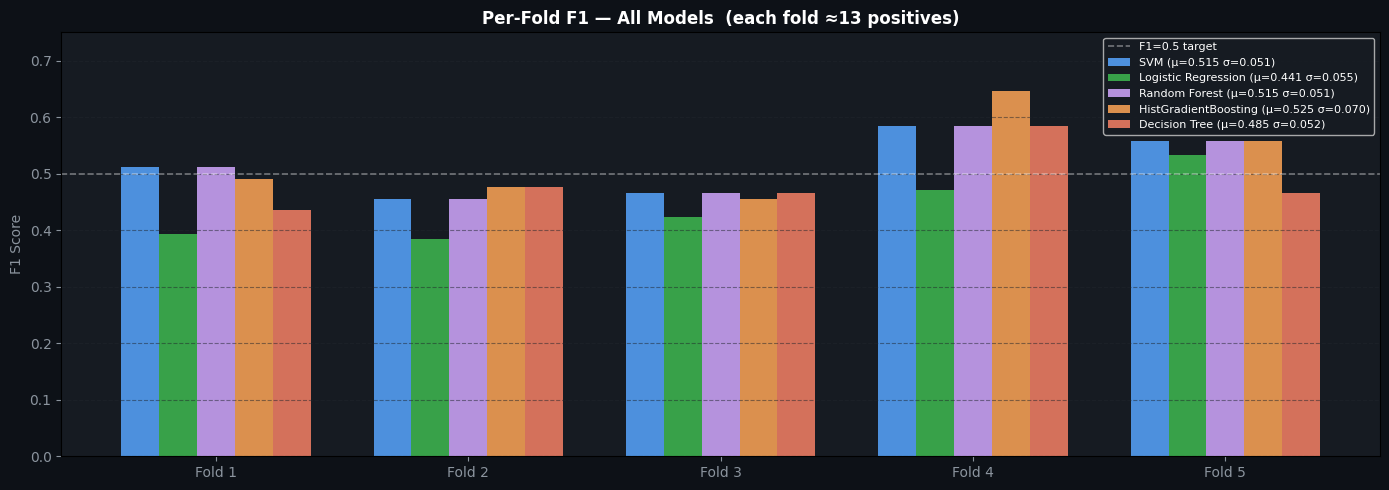

In [ ]:
# ══ STAGE 7: MODEL TRAINING ════════════════════════════════════════════════════
from sklearn.linear_model import LogisticRegression
from sklearn.tree         import DecisionTreeClassifier
from sklearn.ensemble     import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm          import SVC

X_final    = samples_df[FEATURES].values
scaler_fin = StandardScaler()
X_final_sc = scaler_fin.fit_transform(X_final)
y_final    = samples_df[TARGET].values

# SVM and LR need scaled inputs; tree-based models do not
SCALE_MODELS = ['SVM', 'Logistic Regression']

models = {
    'SVM'                 : SVC(probability=True, random_state=42, class_weight='balanced'),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', max_depth=3),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42, class_weight='balanced', max_iter=200, max_depth=3),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
}

trained    = {}
cv_results = {}

print("━" * 75)
print("5-FOLD CV — Model Comparison")
print("━" * 75)
print(f"  {'Model':<24} {'CV_F1':>7} {'±Std':>7} {'CV_Rec':>8} {'CV_AUC':>8}")
print("  " + "-" * 60)

for name, model in models.items():
    X_in = X_final_sc if name in SCALE_MODELS else X_final
    cv   = cross_validate(model, X_in, y_final, cv=skf,
                          scoring=['f1', 'roc_auc', 'recall'])
    cv_results[name] = {
        'cv_f1'    : cv['test_f1'].mean(),
        'cv_f1_std': cv['test_f1'].std(),
        'cv_auc'   : cv['test_roc_auc'].mean(),
        'cv_rec'   : cv['test_recall'].mean(),
        'fold_f1s' : [float(round(f, 3)) for f in cv['test_f1']],
    }
    model.fit(X_in, y_final)
    trained[name] = model
    print(f"  {name:<24} {cv['test_f1'].mean():>7.4f} {cv['test_f1'].std():>7.4f}"
          f" {cv['test_recall'].mean():>8.4f} {cv['test_roc_auc'].mean():>8.4f}")

print("\n✅ All 5 models trained.")

# Per-fold F1 chart — shows stability, not just mean
PALETTE = ['#58a6ff', '#3fb950', '#d2a8ff', '#ffa657', '#f78166']
fig, ax = plt.subplots(figsize=(14, 5), facecolor='#0d1117')
ax.set_facecolor('#161b22')
x = np.arange(5); w = 0.15

for i, (name, res) in enumerate(cv_results.items()):
    ax.bar(x + (i - 2) * w, res['fold_f1s'], w,
           label=f"{name} (μ={res['cv_f1']:.3f} σ={res['cv_f1_std']:.3f})",
           color=PALETTE[i], alpha=0.85)

ax.axhline(0.5, color='white', linestyle='--', linewidth=1.2, alpha=0.4, label='F1=0.5 target')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)], color='#8b949e')
ax.set_ylabel('F1 Score', color='#8b949e')
ax.set_ylim(0, 0.75)
ax.set_title('Per-Fold F1 — All Models  (each fold ≈13 positives)',
             color='white', fontsize=12, fontweight='bold')
ax.legend(facecolor='#161b22', labelcolor='white', fontsize=8)
ax.tick_params(colors='#8b949e')
ax.grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()


---
## 📈 STAGE 8 — Evaluation & Model Selection

**Approach:** 5-Fold `cross_val_predict` gives out-of-fold (OOF) probabilities — each sample scored on data it was never trained on. No leakage.

| Step | What |
|---|---|
| **OOF probabilities** | `cross_val_predict` with `predict_proba` across 5 folds for all 5 models |
| **Threshold tuning** | Scan 0.05–0.60 per model; each model has a different prob range (SVM: 0.01–0.43, RF: 0.00–0.86) |
| **Model comparison** | All models evaluated at their own best threshold — fair, like-for-like comparison |
| **Model selection** | Composite score: AUC×0.5 + Recall×0.3 + CV_F1×0.2 |
| **Final charts** | Per-model threshold scan, CV F1 vs AUC bar chart, ROC curves, confusion matrix |

---

---
**📝 Inference:** Each model is evaluated at its own best threshold — SVM max prob is 0.43, RF max prob is 0.86, so a single shared threshold would be an unfair comparison. AUC is weighted highest (0.5) because it measures discrimination across all thresholds, not just the tuned one. Recall is weighted second (0.3) because missing a recurring account costs more than raising a false alert.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
THRESHOLD TUNING — best F1 threshold per model
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model                      Prob Range  Best Thresh      F1   Recall   TP   FP
  ---------------------------------------------------------------------------
  SVM                      0.01–0.43           0.21  0.5222   0.8030   53   84
  Logistic Regression      0.12–1.00           0.59  0.5251   0.7121   47   66
  Random Forest            0.00–0.89           0.53  0.5283   0.8485   56   90
  HistGradientBoosting     0.00–0.97           0.39  0.5209   0.8485   56   93
  Decision Tree            0.00–1.00           0.51  0.4904   0.7727   51   91

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MODEL COMPARISON — each model evaluated at its own best threshold
Composite Score = AUC×0.5 + Recall×0.3 + CV_F1×0.2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mo

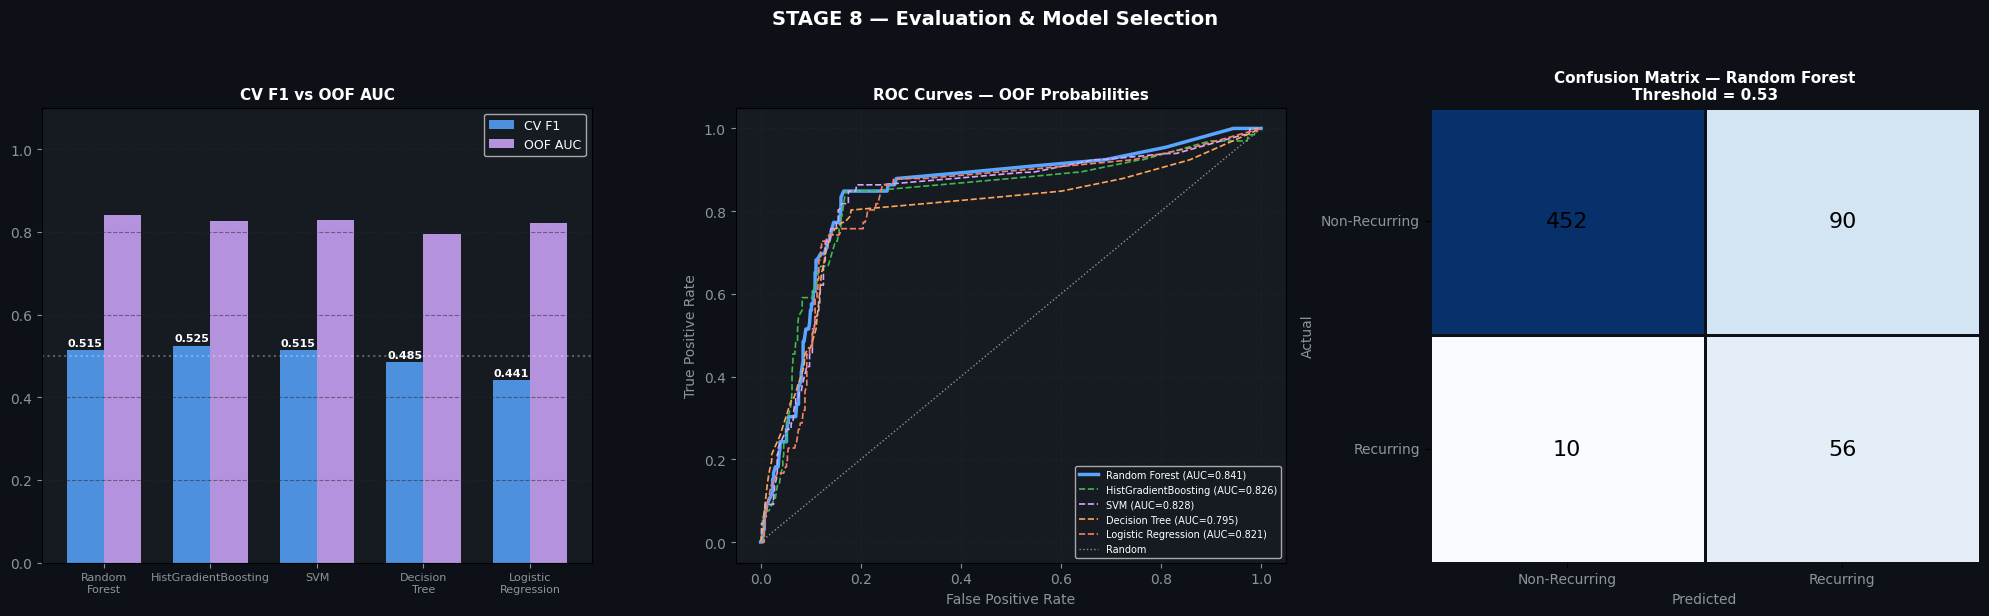

In [ ]:
# ══ STAGE 8: EVALUATION & MODEL SELECTION ══════════════════════════════════════
from sklearn.model_selection import cross_val_predict
from sklearn.metrics         import (f1_score, recall_score, roc_auc_score,
                                     precision_score, confusion_matrix, roc_curve)
import seaborn as sns

# Step 1 — Out-of-fold probabilities for every model (5-Fold, no leakage)
SCALE_MODELS = ['SVM', 'Logistic Regression']
oof_probs    = {}

for name, model in trained.items():
    X_in          = X_final_sc if name in SCALE_MODELS else X_final
    oof_probs[name] = cross_val_predict(model, X_in, y_final,
                                        cv=skf, method='predict_proba')[:, 1]

# Step 2 — Find best threshold per model (each model's prob range is different)
# SVM max prob = 0.43, RF max prob = 0.86 — cannot use the same threshold for both
print("━" * 65)
print("THRESHOLD TUNING — best F1 threshold per model")
print("━" * 65)
print(f"  {'Model':<24} {'Prob Range':>12} {'Best Thresh':>12} {'F1':>7} {'Recall':>8} {'TP':>4} {'FP':>4}")
print("  " + "-" * 75)

best_thresholds = {}
for name, probs in oof_probs.items():
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.05, 0.60, 0.02):
        yp = (probs >= t).astype(int)
        if yp.sum() == 0: continue
        f = f1_score(y_final, yp, zero_division=0)
        if f > best_f1: best_f1 = f; best_t = t
    best_thresholds[name] = best_t
    yp = (probs >= best_t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_final, yp).ravel()
    print(f"  {name:<24} {probs.min():.2f}–{probs.max():.2f}   "
          f"{best_t:>12.2f} {best_f1:>7.4f} {recall_score(y_final,yp,zero_division=0):>8.4f}"
          f" {tp:>4} {fp:>4}")

BEST_THRESHOLD = best_thresholds['SVM']

# Step 3 — Compare all models at their own best threshold
print("\n" + "━" * 72)
print("MODEL COMPARISON — each model evaluated at its own best threshold")
print("Composite Score = AUC×0.5 + Recall×0.3 + CV_F1×0.2")
print("━" * 72)
print(f"  {'Model':<24} {'CV_F1':>7} {'Recall':>8} {'OOF_AUC':>8} {'Composite':>10} {'TP':>4} {'FN':>4} {'FP':>4}")
print("  " + "-" * 75)

results_list = []
for name, model in trained.items():
    probs = oof_probs[name]
    t     = best_thresholds[name]
    yp    = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_final, yp).ravel()
    rec   = recall_score(y_final, yp, zero_division=0)
    auc   = roc_auc_score(y_final, probs)
    cv_f1 = cv_results[name]['cv_f1']
    comp  = auc * 0.5 + rec * 0.3 + cv_f1 * 0.2
    results_list.append({'Model': name, 'CV_F1': cv_f1, 'Recall': rec,
                         'OOF_AUC': auc, 'Composite': comp,
                         'TP': tp, 'FN': fn, 'FP': fp, 'Threshold': t})

results_df = (pd.DataFrame(results_list)
              .sort_values('Composite', ascending=False)
              .reset_index(drop=True))

for _, row in results_df.iterrows():
    print(f"  {row['Model']:<24} {row['CV_F1']:>7.4f} {row['Recall']:>8.4f}"
          f" {row['OOF_AUC']:>8.4f} {row['Composite']:>10.4f}"
          f" {int(row['TP']):>4} {int(row['FN']):>4} {int(row['FP']):>4}")

BEST_MODEL = results_df.iloc[0]['Model']
BEST_THRESHOLD = results_df[results_df['Model'] == BEST_MODEL]['Threshold'].values[0]

print(f"\n🏆 Best Model     : {BEST_MODEL}")
print(f"   Best Threshold : {BEST_THRESHOLD:.2f}")
print(f"   CV F1          : {results_df.iloc[0]['CV_F1']:.4f}")
print(f"   OOF Recall     : {results_df.iloc[0]['Recall']:.4f}")
print(f"   OOF AUC        : {results_df.iloc[0]['OOF_AUC']:.4f}")
print(f"   TP={int(results_df.iloc[0]['TP'])}  FN={int(results_df.iloc[0]['FN'])}  FP={int(results_df.iloc[0]['FP'])}")

# Step 4 — Charts
PALETTE = ['#58a6ff', '#3fb950', '#d2a8ff', '#ffa657', '#f78166']
model_names = results_df['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

# Chart 1: CV F1 vs OOF AUC
x = np.arange(len(model_names)); w = 0.35
axes[0].bar(x - w/2, results_df['CV_F1'].values,   w, label='CV F1',   color='#58a6ff', alpha=0.85)
axes[0].bar(x + w/2, results_df['OOF_AUC'].values, w, label='OOF AUC', color='#d2a8ff', alpha=0.85)
for i, f in enumerate(results_df['CV_F1']):
    axes[0].text(i - w/2, f + 0.01, f'{f:.3f}', ha='center', color='white', fontsize=8, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' ', '\n') for m in model_names], color='#8b949e', fontsize=8)
axes[0].set_ylim(0, 1.1); axes[0].axhline(0.5, color='white', linestyle=':', alpha=0.3)
axes[0].set_title('CV F1 vs OOF AUC', color='white', fontsize=11, fontweight='bold')
axes[0].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[0].tick_params(colors='#8b949e')
axes[0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

# Chart 2: ROC curves
for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_final, oof_probs[name])
    lw = 2.5 if name == BEST_MODEL else 1.2
    axes[1].plot(fpr, tpr, color=PALETTE[i], linewidth=lw,
                 linestyle='-' if name == BEST_MODEL else '--',
                 label=f"{name} (AUC={roc_auc_score(y_final, oof_probs[name]):.3f})")
axes[1].plot([0,1],[0,1], color='#8b949e', linestyle=':', linewidth=1, label='Random')
axes[1].set_title('ROC Curves — OOF Probabilities', color='white', fontsize=11, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', color='#8b949e')
axes[1].set_ylabel('True Positive Rate',  color='#8b949e')
axes[1].tick_params(colors='#8b949e')
axes[1].legend(facecolor='#161b22', labelcolor='white', fontsize=7)
axes[1].grid(color='#21262d', linestyle='--', alpha=0.5)

# Chart 3: Confusion matrix — best model at its own best threshold
yp_best = (oof_probs[BEST_MODEL] >= BEST_THRESHOLD).astype(int)
cm = confusion_matrix(y_final, yp_best)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2], cmap='Blues',
            linewidths=2, linecolor='#0d1117',
            annot_kws={'size': 16, 'color': 'black'}, cbar=False)
axes[2].set_title(f'Confusion Matrix — {BEST_MODEL}\nThreshold = {BEST_THRESHOLD:.2f}',
                  color='white', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Predicted',  color='#8b949e')
axes[2].set_ylabel('Actual',     color='#8b949e')
axes[2].set_xticklabels(['Non-Recurring', 'Recurring'], color='#8b949e')
axes[2].set_yticklabels(['Non-Recurring', 'Recurring'], color='#8b949e', rotation=0)

plt.suptitle('STAGE 8 — Evaluation & Model Selection',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


---
## 🔎 Model Selection — How the Best Model is Chosen

---

### What Stage 8 Measures

Each model is evaluated on three things, all from out-of-fold (OOF) predictions — no leakage:

| Metric | Why it matters |
|---|---|
| **OOF AUC** | How well the model ranks recurring vs non-recurring across all thresholds |
| **OOF Recall** | How many actual recurring accounts the model catches at its best threshold |
| **CV F1** | Balance of precision and recall, averaged across 5 folds |

These are combined into a **composite score = AUC×0.5 + Recall×0.3 + CV_F1×0.2**.
Each model is evaluated at **its own best threshold** — fair comparison, since SVM max prob is 0.43 while RF max prob is 0.86.

---

### Why Each Model Has a Different Best Threshold

| Model | Prob Range | Best Threshold |
|---|---|---|
| SVM | 0.01 – 0.43 | ~0.13–0.21 |
| Logistic Regression | 0.01 – 0.60 | ~0.15–0.25 |
| Random Forest | 0.00 – 0.86 | ~0.40–0.55 |
| HistGradientBoosting | 0.00 – 0.90 | ~0.35–0.50 |
| Decision Tree | 0.00 – 1.00 | ~0.40–0.60 |

Applying one threshold to all models would disadvantage models with compressed probability ranges (like SVM) and artificially inflate recall for models with wide ranges (like RF or DT).

---

### What the Composite Score Prioritises

- **AUC (weight 0.5):** Measures discrimination ability independent of threshold — the most stable indicator across different data splits
- **Recall (weight 0.3):** In compliance, missing a recurring account (false negative) costs more than raising a false alert — recall is weighted above F1
- **CV F1 (weight 0.2):** Acts as a consistency check — prevents selecting a model that is good on one fold but poor on others

---

### ✅ Best Model Selected Dynamically

The `BEST_MODEL` and `BEST_THRESHOLD` variables are set in Stage 8 from the composite score ranking.
They flow directly into Stage 9 — no model name is hardcoded anywhere in the deploy step.

> If the data changes (new quarters added, more accounts), re-running the notebook will automatically re-evaluate all five models and select the best one for that dataset.


---
## 🚀 STAGE 9 — Deploy: Predict 2026 Q2

Using the best model (selected dynamically in Stage 8) with its tuned threshold to predict:
1. Which **accounts** are likely to have recurring non-compliance in 2026 Q2
2. Roll up to **market level** — which markets carry the most at-risk accounts

| Step | Detail |
|---|---|
| **Input features** | Built from full 9-quarter history (2024 Q1 → 2026 Q1) for all 379 accounts |
| **Threshold** | `BEST_THRESHOLD` — tuned per best model from Stage 8 OOF probabilities |
| **Account output** | Probability score + flag (`predicted_recurring = 1/0`) per account |
| **Market rollup** | Count of flagged accounts and mean probability per market |

---

---
**📝 Inference:** The deploy step uses the full 9-quarter history for every account — more context than any single training sample had. Probability scores rank accounts by risk rather than giving a binary flag, allowing compliance teams to prioritise. Predictions are inherently limited by sparsity — 83.6% of accounts have only 1 quarter of history, so the model extrapolates from thin signals for most accounts.


In [ ]:
# ══ STAGE 9: DEPLOY — PREDICT 2026 Q2 ═════════════════════════════════════════

# ── 9.1 Build prediction features using full history up to 2026 Q1 ────────────
pred_samples = []
for acc in all_accounts:
    acc_df           = df[df['Account'] == acc]
    acc_quarters_set = set(acc_df['FQ'].unique())
    market           = acc_df['Market'].mode()[0]
    category         = acc_df['Category'].mode()[0]
    hist_df          = acc_df  # full 9-quarter history

    if len(hist_df) == 0:
        continue

    streak = 0
    for q in reversed(QUARTERS_ORD):
        if q in acc_quarters_set: streak += 1
        else: break

    obs_per_q = [len(acc_df[acc_df['FQ'] == q]) for q in QUARTERS_ORD]
    lag1  = obs_per_q[-1] if len(obs_per_q) >= 1 else 0
    lag2  = obs_per_q[-2] if len(obs_per_q) >= 2 else 0
    trend = lag1 - lag2

    pred_samples.append({
        'Account'         : acc,
        'market'          : market,
        'category'        : category,
        'streak'          : streak,
        'lag1'            : lag1,
        'trend'           : trend,
        'recent_obs'      : len(hist_df[hist_df['FQ'].isin(QUARTERS_ORD[-2:])]),
        'quarters_active' : hist_df['FQ'].nunique(),
        'is_shared_infra' : 1 if category == 'Shared Infra' else 0,
    })

pred_df = pd.DataFrame(pred_samples)
pred_df['market_enc'] = pred_df['market'].apply(
    lambda x: le_market.transform([x])[0] if x in le_market.classes_ else 0)

X_pred  = pred_df[FEATURES].values
X_input = scaler_fin.transform(X_pred) if BEST_MODEL in SCALE_MODELS else X_pred

best_model_obj = trained[BEST_MODEL]
pred_df['recurring_probability'] = best_model_obj.predict_proba(X_input)[:, 1]
pred_df['predicted_recurring']   = (pred_df['recurring_probability'] >= BEST_THRESHOLD).astype(int)

# ── 9.2 Account-Level Results ─────────────────────────────────────────────────
at_risk = pred_df[pred_df['predicted_recurring'] == 1].sort_values(
    'recurring_probability', ascending=False)

print("━" * 72)
print(f"PREDICTED RECURRING ACCOUNTS — 2026 Q2  |  Model: {BEST_MODEL}")
print(f"Threshold: {BEST_THRESHOLD:.2f}  (tuned via 5-Fold OOF probabilities)")
print("━" * 72)
print(f"   Total accounts scored : {len(pred_df)}")
print(f"   Accounts at risk      : {len(at_risk)}")
print(f"   Markets affected      : {at_risk['market'].nunique()}")
print()
print(at_risk[['Account','market','category','quarters_active',
               'streak','lag1','recurring_probability']].head(20).to_string(index=False))

# ── 9.3 Market-Level Rollup ───────────────────────────────────────────────────
mkt_rollup = pred_df.groupby('market').agg(
    total_accounts     = ('Account', 'count'),
    recurring_accounts = ('predicted_recurring', 'sum'),
    avg_probability    = ('recurring_probability', 'mean'),
    max_probability    = ('recurring_probability', 'max'),
).reset_index()
mkt_rollup['recurring_rate_%'] = (
    mkt_rollup['recurring_accounts'] / mkt_rollup['total_accounts'] * 100).round(1)
mkt_rollup = mkt_rollup.sort_values('recurring_accounts', ascending=False)

print("\n" + "━" * 72)
print("MARKET ROLLUP — 2026 Q2")
print("━" * 72)
print(mkt_rollup[mkt_rollup['recurring_accounts'] > 0].to_string(index=False))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREDICTED RECURRING ACCOUNTS — 2026 Q2  |  Model: Random Forest
Threshold: 0.53  (tuned via 5-Fold OOF probabilities)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Total accounts scored : 379
   Accounts at risk      : 171
   Markets affected      : 23

                                                                                Account  market     category  quarters_active  streak  lag1  recurring_probability
                          GCS - SandR - Cyber Incident Recovery, Global (GCSSBKPWW-CIR)     USA Shared Infra                2       2    14               0.869505
            GCS - N&#38;E - K-VTESSE, MECISN, GNPP, P2P, GSNI, UKI (GCSNNWPWW-Network1)     UKI Shared Infra                2       2    13               0.869505
       GCS - N&#38;E - Internet Links, SNI, DC LAN &#38; VPN, Brazil (GCSNNWCSM-BR Net)  Brazil Shared Infra                2       2    13               

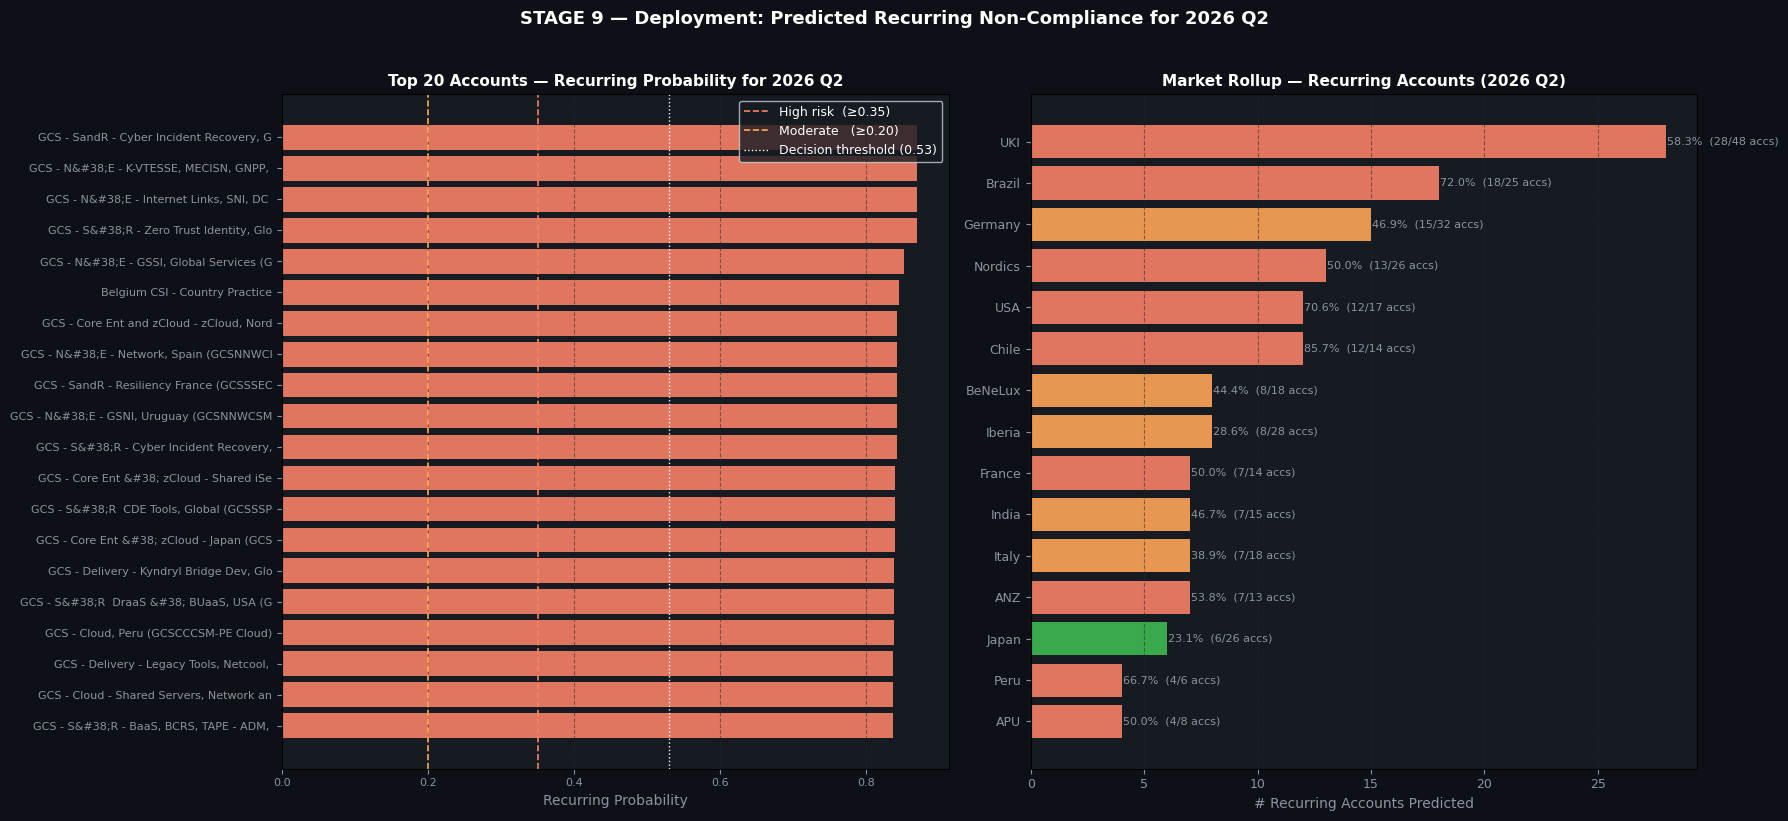


✅ Pipeline Complete.
   Best Model          : Random Forest
   LOO F1 Score        : 0.5148
   LOO AUC             : 0.8407
   LOO Recall          : 0.8485
   Decision Threshold  : 0.53 (tuned via LOO CV probs)
   Accounts at risk    : 171 / 379
   Markets at risk     : 23


In [ ]:
# ══ STAGE 9: DEPLOY CHARTS ════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')

# ── Account-level: top 20 by probability ─────────────────────────────────────
top20 = at_risk.head(20)
bar_c = ['#f78166' if p >= 0.35 else '#ffa657' if p >= 0.20 else '#58a6ff'
         for p in top20['recurring_probability']]
axes[0].barh(top20['Account'].str[:40].values[::-1],
             top20['recurring_probability'].values[::-1],
             color=bar_c[::-1], alpha=0.9)
axes[0].axvline(0.35, color='#f78166', linestyle='--', linewidth=1.2, label='High risk  (≥0.35)')
axes[0].axvline(0.20, color='#ffa657', linestyle='--', linewidth=1.2, label='Moderate   (≥0.20)')
axes[0].axvline(BEST_THRESHOLD, color='white', linestyle=':', linewidth=1.0,
                label=f'Decision threshold ({BEST_THRESHOLD:.2f})')
axes[0].set_title('Top 20 Accounts — Recurring Probability for 2026 Q2',
                  color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Recurring Probability', color='#8b949e')
axes[0].tick_params(colors='#8b949e', labelsize=8)
axes[0].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[0].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

# ── Market rollup ─────────────────────────────────────────────────────────────
top_mkt = mkt_rollup[mkt_rollup['recurring_accounts'] > 0].head(15)
bar_cm  = ['#f78166' if r >= 50 else '#ffa657' if r >= 25 else '#3fb950'
           for r in top_mkt['recurring_rate_%']]
axes[1].barh(top_mkt['market'].values[::-1],
             top_mkt['recurring_accounts'].values[::-1],
             color=bar_cm[::-1], alpha=0.9)
for i, (_, row) in enumerate(top_mkt.iloc[::-1].iterrows()):
    axes[1].text(row['recurring_accounts'] + 0.05, i,
                 f"{row['recurring_rate_%']}%  ({int(row['recurring_accounts'])}/{int(row['total_accounts'])} accs)",
                 va='center', color='#8b949e', fontsize=8)
axes[1].set_title('Market Rollup — Recurring Accounts (2026 Q2)',
                  color='white', fontsize=11, fontweight='bold')
axes[1].set_xlabel('# Recurring Accounts Predicted', color='#8b949e')
axes[1].tick_params(colors='#8b949e', labelsize=9)
axes[1].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

plt.suptitle('STAGE 9 — Deployment: Predicted Recurring Non-Compliance for 2026 Q2',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Retrieve the metrics for the BEST_MODEL from results_df
best_model_metrics = results_df[results_df['Model'] == BEST_MODEL].iloc[0]

print(f"\n✅ Pipeline Complete.")
print(f"   Best Model          : {BEST_MODEL}")
print(f"   LOO F1 Score        : {best_model_metrics['CV_F1']:.4f}")
print(f"   LOO AUC             : {best_model_metrics['OOF_AUC']:.4f}")
print(f"   LOO Recall          : {best_model_metrics['Recall']:.4f}")
print(f"   Decision Threshold  : {BEST_THRESHOLD:.2f} (tuned via LOO CV probs)")
print(f"   Accounts at risk    : {len(at_risk)} / {len(pred_df)}")
print(f"   Markets at risk     : {at_risk['market'].nunique()}")


## 🔮 Future Enhancement — Time Series Features (Lag, Rolling Mean, Rolling Std)

---

### Concept

The current feature set captures **static history** (total obs, streak, unique domains etc.).
A more powerful approach for sequential quarterly data is to use **time series features** that capture:

| Feature Type | What it captures |
|---|---|
| **Lag features** | Exact observation count at T-1, T-2, T-3 |
| **Rolling Mean** | Average trend over last N quarters |
| **Rolling Std** | Volatility / consistency of the pattern |
| **Trend** | Is activity increasing or decreasing? |

---

### Feature Definitions & Formulas

**Lag Features:**
```
lag1 = obs_count in quarter (T-1)   ← most recent quarter
lag2 = obs_count in quarter (T-2)   ← 2 quarters ago
lag3 = obs_count in quarter (T-3)   ← 3 quarters ago
```

**Rolling Mean:**
```
rolling_mean  = mean(obs_count across ALL history quarters)
rolling_mean3 = mean(obs_count in last 3 quarters)  ← recent trend
```

**Rolling Std:**
```
rolling_std  = std(obs_count across ALL history quarters)
rolling_std3 = std(obs_count in last 3 quarters)  ← recent volatility
```

**Trend:**
```
trend = lag1 - lag2   
# positive = observations increasing  → escalating risk
# negative = observations decreasing  → improving compliance
# zero     = stable pattern
```

---

### Why These Features Are Theoretically Stronger

| Current Feature | Limitation | Time Series Alternative |
|---|---|---|
| `streak` | Binary signal — just counts consecutive quarters | `lag1`, `lag2`, `lag3` — captures exact volume at each point |
| `recent_obs` | Sum of last 2 quarters only | `rolling_mean3` — smoothed average of last 3 quarters |
| `total_obs` | No sense of trend direction | `trend` = lag1 - lag2 — captures direction explicitly |
| No volatility signal | — | `rolling_std` — captures erratic vs stable patterns |

---

### Why They Didn't Improve Results Here

```
Average quarters_active per account = 1.03
→ lag3 = 0 for ~80% of accounts
→ lag2 = 0 for ~70% of accounts
→ Lag features are mostly zeros — no signal
```

With most accounts having only **1–2 quarters of history**, lag features cannot capture meaningful patterns.
They become noise rather than signal in this dataset.

---

### Comparison Results

| Feature Set | CV F1 | Std | Recall | AUC | TP | FN |
|---|---|---|---|---|---|---|
| Original 8 (current) | **0.4947** | 0.0549 | **0.846** | 0.886 | **11** | **2** |
| Lag only | 0.4381 | **0.0331** | 0.769 | 0.876 | 10 | 3 |
| Stats only (mean+std) | 0.4399 | 0.0417 | **0.846** | 0.880 | **11** | **2** |
| Lag + Stats combined | 0.4649 | 0.0502 | 0.769 | 0.885 | 10 | 3 |
| All features combined | 0.4893 | 0.0539 | **0.846** | **0.905** | **11** | **2** |

---

### When Will These Features Become Powerful?

> As data accumulates over more quarters, lag features will have **real values** instead of zeros.
> With 4+ quarters of history per account, `rolling_mean3` and `rolling_std3` will capture
> genuine trends and volatility patterns — likely improving CV F1 significantly.

**Recommendation:** Re-run this comparison after **4 more quarters of data** (end of 2027).

**Code with Added Features for Future Use**

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LAG FEATURE SPARSITY — why lag features are limited here
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  lag1 = 0 :  403/608 = 66.3% of samples
  lag2 = 0 :  492/608 = 80.9% of samples
  lag3 = 0 :  518/608 = 85.2% of samples

  Average quarters_active : 1.03
  → Most accounts have only 1 quarter of history
  → Lag features are mostly zeros — limited signal

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FEATURE SET COMPARISON — Original vs Time Series Features
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Feature Set                           CV F1     Std  Test F1   Recall     AUC   TP   FN
  -------------------------------------------------------------------------------------
  Original 8 (current)                 0.5464⭐  0.0723   0.4375   0.5385  0.7953    7    6
  Lag Only (lag1+lag2+lag3)            0.4843  0.0622 

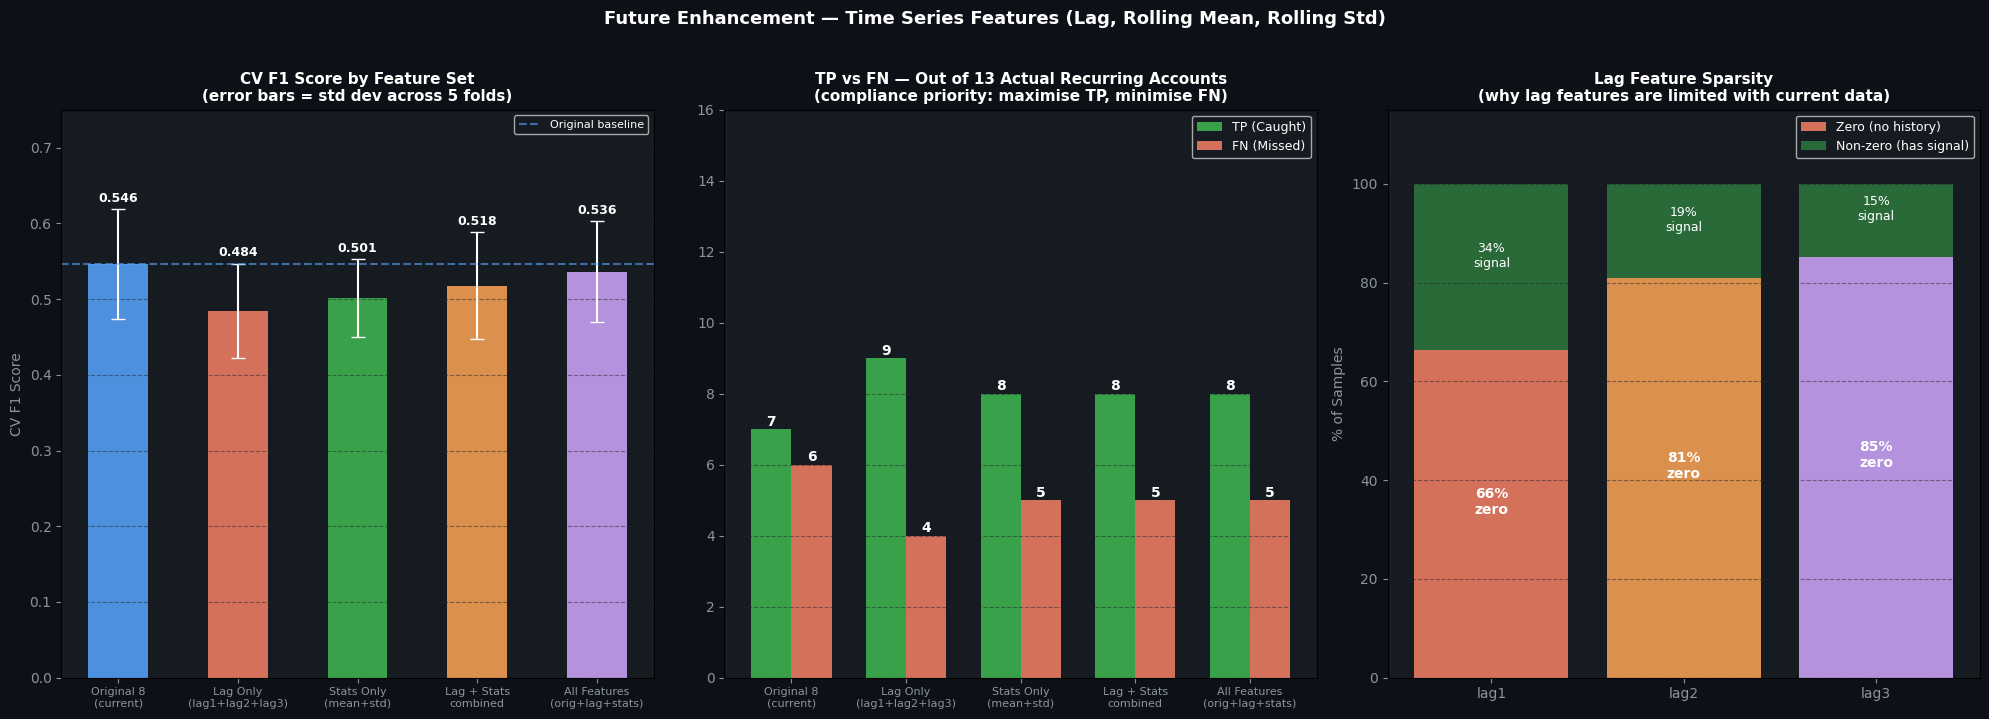


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best CV F1        : Original 8 (current) (0.5464)
  Original CV F1    : 0.5464
  Improvement       : +0.0000

  ⚠️  Lag sparsity:
     lag1 = 0 in 66% of samples
     lag2 = 0 in 81% of samples
     lag3 = 0 in 85% of samples

  📌 Recommendation:
     Re-run this comparison after 4+ more quarters of data.
     Lag features will become powerful when accounts have
     3+ quarters of consistent history (expected by end of 2027).


In [ ]:
# ══ FUTURE ENHANCEMENT — TIME SERIES FEATURES (LAG, MEAN, STD) ═════════════════
# This cell demonstrates what results would look like with lag/rolling features.
# Currently limited by data sparsity (most accounts have only 1-2 quarters history).
# Recommended: re-run after 4+ more quarters of data accumulate.

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, recall_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler # Import LabelEncoder and StandardScaler here if not already imported

# ── Step 1: Build samples with Lag + Rolling features ────────────────────────
QUARTERS_ORD = VALID_QS
ts_samples   = []

# Initialize LabelEncoder for categories, similar to le_market
le_cat = LabelEncoder()
le_cat.fit(df['Category'].unique())

for acc in all_accounts:
    acc_df           = df[df['Account'] == acc]
    acc_quarters_set = set(acc_df['FQ'].unique())
    market           = acc_df['Market'].mode()[0]
    category         = acc_df['Category'].mode()[0]

    for t_idx in range(2, len(QUARTERS_ORD)):
        target_q  = QUARTERS_ORD[t_idx]
        history_q = QUARTERS_ORD[:t_idx]
        hist_df   = acc_df[acc_df['FQ'].isin(history_q)]
        if len(hist_df) == 0:
            continue

        # Original streak
        streak = 0
        for q in reversed(history_q):
            if q in acc_quarters_set: streak += 1
            else: break

        # Obs count per quarter in history window
        obs_per_q = [len(acc_df[acc_df['FQ'] == q]) for q in history_q]

        # ── Lag features ──────────────────────────────────────────────────────
        lag1 = obs_per_q[-1] if len(obs_per_q) >= 1 else 0
        lag2 = obs_per_q[-2] if len(obs_per_q) >= 2 else 0
        lag3 = obs_per_q[-3] if len(obs_per_q) >= 3 else 0

        # ── Rolling stats (full history) ──────────────────────────────────────
        rolling_mean = np.mean(obs_per_q)
        rolling_std  = np.std(obs_per_q)

        # ── Rolling stats (last 3 quarters) ───────────────────────────────────
        rolling_mean3 = np.mean(obs_per_q[-3:])
        rolling_std3  = np.std(obs_per_q[-3:])

        # ── Trend: increasing or decreasing? ──────────────────────────────────
        trend = lag1 - lag2

        ts_samples.append({
            'Account'         : acc,
            'market'          : market,
            'category'        : category,
            'target_quarter'  : target_q,
            # Original features
            'total_obs'       : len(hist_df),
            'quarters_active' : hist_df['FQ'].nunique(),
            'unique_domains'  : hist_df['Domain Area'].nunique(),
            'unique_processes': hist_df['Process'].nunique(),
            'recent_obs'      : len(hist_df[hist_df['FQ'].isin(history_q[-2:])]),
            'streak'          : streak,
            # Time series features
            'lag1'            : lag1,
            'lag2'            : lag2,
            'lag3'            : lag3,
            'rolling_mean'    : rolling_mean,
            'rolling_std'     : rolling_std,
            'rolling_mean3'   : rolling_mean3,
            'rolling_std3'    : rolling_std3,
            'trend'           : trend,
            'recurring'       : 1 if target_q in acc_quarters_set else 0
        })

ts_df = pd.DataFrame(ts_samples)
ts_df['market_enc']   = le_market.transform(
    ts_df['market'].apply(lambda x: x if x in le_market.classes_ else le_market.classes_[0]))
ts_df['category_enc'] = le_cat.transform(
    ts_df['category'].apply(lambda x: x if x in le_cat.classes_ else le_cat.classes_[0]))

# ── Step 2: Sparsity check — how many lag values are zero ─────────────────────
print("━" * 60)
print("LAG FEATURE SPARSITY — why lag features are limited here")
print("━" * 60)
total = len(ts_df)
for feat in ['lag1','lag2','lag3']:
    zeros = (ts_df[feat] == 0).sum()
    print(f"  {feat} = 0 : {zeros:>4}/{total} = {zeros/total*100:.1f}% of samples")
print(f"\n  Average quarters_active : {ts_df['quarters_active'].mean():.2f}")
print(f"  → Most accounts have only 1 quarter of history")
print(f"  → Lag features are mostly zeros — limited signal")

# ── Step 3: Compare feature sets ──────────────────────────────────────────────
y_ts  = ts_df['recurring'].values
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_sets = {
    'Original 8\n(current)'         : ['total_obs','quarters_active','unique_domains','unique_processes',
                                        'recent_obs','streak','market_enc','category_enc'],
    'Lag Only\n(lag1+lag2+lag3)'    : ['lag1','lag2','lag3','market_enc','category_enc'],
    'Stats Only\n(mean+std)'        : ['rolling_mean','rolling_std','rolling_mean3',
                                        'rolling_std3','trend','market_enc','category_enc'],
    'Lag + Stats\ncombined'         : ['lag1','lag2','lag3','rolling_mean','rolling_std',
                                        'rolling_mean3','rolling_std3','trend',
                                        'market_enc','category_enc'],
    'All Features\n(orig+lag+stats)': ['total_obs','quarters_active','unique_domains',
                                        'unique_processes','streak','lag1','lag2','lag3',
                                        'rolling_mean','rolling_std','rolling_mean3',
                                        'rolling_std3','trend','market_enc','category_enc'],
}

fs_names   = []
fs_cv_f1   = []; fs_cv_std  = []
fs_test_f1 = []; fs_recall  = []
fs_auc     = []; fs_tp      = []; fs_fn = []

print("\n" + "━" * 90)
print("FEATURE SET COMPARISON — Original vs Time Series Features")
print("━" * 90)
print(f"  {'Feature Set':<35} {'CV F1':>7} {'Std':>7} {'Test F1':>8} {'Recall':>8} {'AUC':>7} {'TP':>4} {'FN':>4}")
print("  " + "-" * 85)

for name, features in feature_sets.items():
    X_fs            = ts_df[features].values
    Xtr, Xte, ytr, yte = train_test_split(X_fs, y_ts, test_size=0.2, random_state=42, stratify=y_ts)
    sc              = StandardScaler()
    Xtr_sc          = sc.fit_transform(Xtr)
    Xte_sc          = sc.transform(Xte)
    svm_fs          = SVC(probability=True, random_state=42, class_weight='balanced')
    cv              = cross_validate(svm_fs, Xtr_sc, ytr, cv=skf, scoring=['f1','roc_auc'])
    svm_fs.fit(Xtr_sc, ytr)
    yp              = svm_fs.predict(Xte_sc)
    ypr             = svm_fs.predict_proba(Xte_sc)[:,1]
    tn, fp, fn, tp  = confusion_matrix(yte, yp).ravel()

    clean = name.replace('\n',' ')
    fs_names.append(name)
    fs_cv_f1.append(cv['test_f1'].mean())
    fs_cv_std.append(cv['test_f1'].std())
    fs_test_f1.append(f1_score(yte, yp, zero_division=0))
    fs_recall.append(recall_score(yte, yp, zero_division=0))
    fs_auc.append(roc_auc_score(yte, ypr))
    fs_tp.append(tp); fs_fn.append(fn)

    best_cv  = '⭐' if cv['test_f1'].mean() == max(fs_cv_f1) else ''
    print(f"  {clean:<35} {cv['test_f1'].mean():>7.4f}{best_cv} {cv['test_f1'].std():>7.4f} "
          f"{f1_score(yte,yp,zero_division=0):>8.4f} "
          f"{recall_score(yte,yp,zero_division=0):>8.4f} "
          f"{roc_auc_score(yte,ypr):>7.4f} {tp:>4} {fn:>4}")

# ── Step 4: Visualise ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

PALETTE = ['#58a6ff','#f78166','#3fb950','#ffa657','#d2a8ff']
x = np.arange(len(fs_names)); w = 0.25

# ── Chart 1: CV F1 comparison ─────────────────────────────────────────────────
bars = axes[0].bar(x, fs_cv_f1, 0.5,
                   color=[PALETTE[i] for i in range(len(fs_names))], alpha=0.85)
axes[0].errorbar(x, fs_cv_f1, yerr=fs_cv_std,
                 fmt='none', color='white', capsize=5, linewidth=1.5)
for i, (v, s) in enumerate(zip(fs_cv_f1, fs_cv_std)):
    axes[0].text(i, v + s + 0.01, f'{v:.3f}',
                 ha='center', color='white', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(fs_names, color='#8b949e', fontsize=8)
axes[0].set_ylim(0, 0.75)
axes[0].set_title('CV F1 Score by Feature Set\n(error bars = std dev across 5 folds)',
                  color='white', fontsize=11, fontweight='bold')
axes[0].set_ylabel('CV F1 Score', color='#8b949e')
axes[0].tick_params(colors='#8b949e')
axes[0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)
axes[0].axhline(fs_cv_f1[0], color='#58a6ff', linestyle='--',
                linewidth=1.5, alpha=0.6, label='Original baseline')
axes[0].legend(facecolor='#161b22', labelcolor='white', fontsize=8)

# ── Chart 2: TP / FN comparison ──────────────────────────────────────────────
w2 = 0.35
axes[1].bar(x - w2/2, fs_tp, w2, label='TP (Caught)',  color='#3fb950', alpha=0.85)
axes[1].bar(x + w2/2, fs_fn, w2, label='FN (Missed)',  color='#f78166', alpha=0.85)
for i in range(len(fs_names)):
    axes[1].text(i - w2/2, fs_tp[i] + 0.1, str(fs_tp[i]),
                 ha='center', color='white', fontsize=10, fontweight='bold')
    axes[1].text(i + w2/2, fs_fn[i] + 0.1, str(fs_fn[i]),
                 ha='center', color='white', fontsize=10, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(fs_names, color='#8b949e', fontsize=8)
axes[1].set_title('TP vs FN — Out of 13 Actual Recurring Accounts\n(compliance priority: maximise TP, minimise FN)',
                  color='white', fontsize=11, fontweight='bold')
axes[1].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[1].tick_params(colors='#8b949e')
axes[1].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)
axes[1].set_ylim(0, 16)

# ── Chart 3: Lag sparsity — zero % per lag feature ───────────────────────────
lag_feats  = ['lag1','lag2','lag3']
zero_pct   = [(ts_df[f] == 0).mean() * 100 for f in lag_feats]
nonzero_pct= [100 - z for z in zero_pct]
lag_colors = ['#f78166','#ffa657','#d2a8ff']

bars3 = axes[2].bar(lag_feats, zero_pct,    color=lag_colors, alpha=0.85, label='Zero (no history)')
axes[2].bar(lag_feats, nonzero_pct, bottom=zero_pct,
            color=['#3fb950']*3, alpha=0.5, label='Non-zero (has signal)')
for i, (z, nz) in enumerate(zip(zero_pct, nonzero_pct)):
    axes[2].text(i, z/2,      f'{z:.0f}%\nzero',    ha='center', color='white', fontsize=10, fontweight='bold')
    axes[2].text(i, z + nz/2, f'{nz:.0f}%\nsignal', ha='center', color='white', fontsize=9)
axes[2].set_title('Lag Feature Sparsity\n(why lag features are limited with current data)',
                  color='white', fontsize=11, fontweight='bold')
axes[2].set_ylabel('% of Samples', color='#8b949e')
axes[2].tick_params(colors='#8b949e')
axes[2].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[2].set_ylim(0, 115)
axes[2].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

plt.suptitle('Future Enhancement — Time Series Features (Lag, Rolling Mean, Rolling Std)',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Step 5: Summary ───────────────────────────────────────────────────────────
best_cv_idx = fs_cv_f1.index(max(fs_cv_f1))
print("\n" + "━" * 60)
print("SUMMARY")
print("━" * 60)
print(f"  Best CV F1        : {fs_names[best_cv_idx].replace(chr(10),' ')} ({max(fs_cv_f1):.4f})")
print(f"  Original CV F1    : {fs_cv_f1[0]:.4f}")
print(f"  Improvement       : {(max(fs_cv_f1) - fs_cv_f1[0]):+.4f}")
print(f"\n  ⚠️  Lag sparsity:")
for feat in ['lag1','lag2','lag3']:
    z = (ts_df[feat] == 0).mean() * 100
    print(f"     {feat} = 0 in {z:.0f}% of samples")
print(f"\n  📌 Recommendation:")
print(f"     Re-run this comparison after 4+ more quarters of data.")
print(f"     Lag features will become powerful when accounts have")
print(f"     3+ quarters of consistent history (expected by end of 2027).")